# 🏨 Hotel Booking Dataset - Exploratory Data Analysis

## 📋 Project Overview

This notebook explores the cleaned Hotel Booking dataset to better understand customer behavior and booking patterns.

Using descriptive statistics and visualizations, we analyze cancellations, pricing, seasonality, and other important characteristics of the data before moving on to SQL analysis and dashboard development.

## 🎯 Objectives

The main objectives of this exploratory data analysis are:

- Understand the structure of the dataset
- Explore booking patterns and customer characteristics
- Analyze reservation cancellations
- Compare average daily rates (ADR)
- Identify relationships between important variables
- Prepare insights for the SQL analysis

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
df = pd.read_csv(
    r"C:\Users\Kompiuteris\Downloads\hotel_bookings_cleaned.csv"
)

In [6]:
df.shape

(118559, 32)

## 🏨 Hotel Types

The dataset contains bookings from two hotel types: City Hotels and Resort Hotels.

In this section, we compare the number of bookings for each hotel type to understand how reservations are distributed.

### 🔍 Key Findings

- City Hotels received considerably more bookings than Resort Hotels.
- Approximately two-thirds of all reservations were made at City Hotels.
- This difference should be considered when interpreting the results of later analyses.

In [9]:
df["hotel"].value_counts()

hotel
City Hotel      78894
Resort Hotel    39665
Name: count, dtype: int64

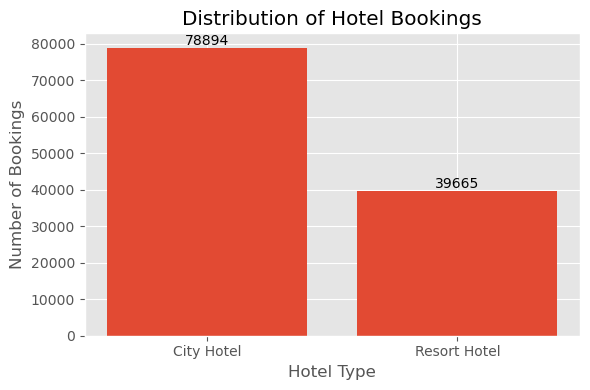

In [17]:
hotel_counts = df["hotel"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(hotel_counts.index, hotel_counts.values)

plt.title("Distribution of Hotel Bookings")
plt.xlabel("Hotel Type")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

In [20]:
df["arrival_date_year"].value_counts().sort_index()

arrival_date_year
2015    21816
2016    56234
2017    40509
Name: count, dtype: int64

In [22]:
df["arrival_date_month"].value_counts()

arrival_date_month
August       13808
July         12586
May          11704
October      11064
April        11045
June         10891
September    10477
March         9714
February      7998
November      6712
December      6689
January       5871
Name: count, dtype: int64

## 📅 Booking Distribution Over Time

Booking activity may vary across different years and months due to seasonal demand and the time period covered by the dataset.

In this section, we examine how bookings are distributed over time to identify overall trends and seasonal patterns.

### 🔍 Key Findings

- The highest number of bookings was recorded in 2016.
- Booking activity peaked during the summer months, especially in July and August.
- January had the lowest number of bookings.

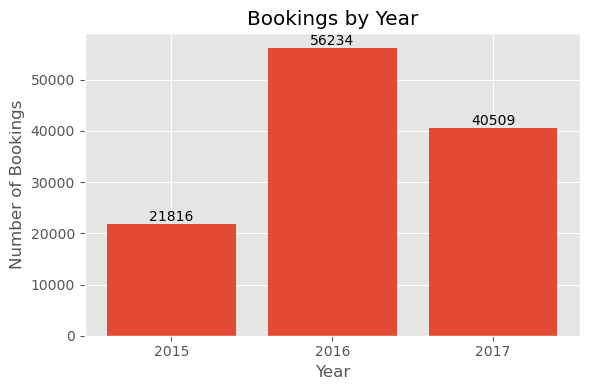

In [27]:
year_counts = df["arrival_date_year"].value_counts().sort_index()

plt.figure(figsize=(6,4))

bars = plt.bar(year_counts.index.astype(str), year_counts.values)

plt.title("Bookings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

In [29]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

month_counts = (
    df["arrival_date_month"]
    .value_counts()
    .reindex(month_order)
)

month_counts

arrival_date_month
January       5871
February      7998
March         9714
April        11045
May          11704
June         10891
July         12586
August       13808
September    10477
October      11064
November      6712
December      6689
Name: count, dtype: int64

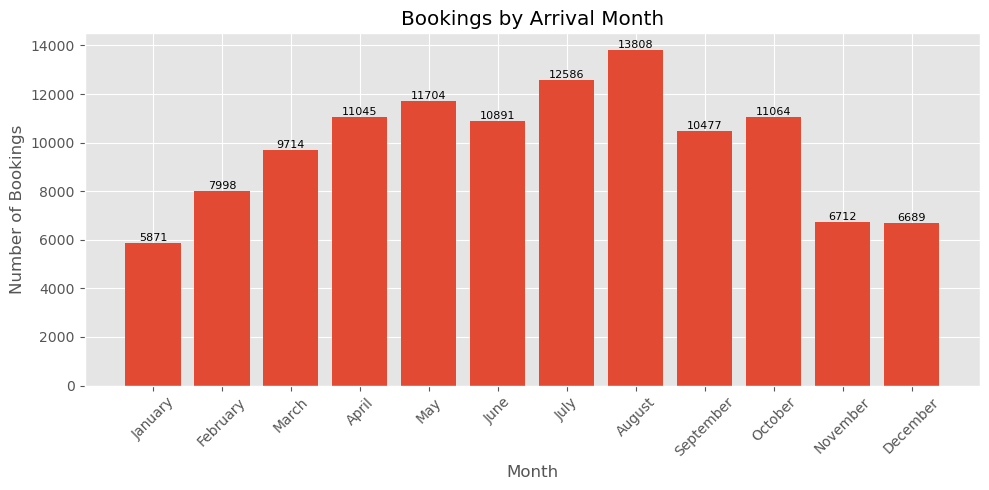

In [31]:
plt.figure(figsize=(10,5))

bars = plt.bar(month_counts.index, month_counts.values)

plt.title("Bookings by Arrival Month")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f", fontsize=8)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 📉 Reservation Status

Every reservation in the dataset ends with one of three outcomes: Check-Out, Canceled, or No-Show.

In this section, we examine how bookings are distributed across these reservation statuses.

### 🔍 Key Findings

- Most reservations ended with a successful check-out.
- A substantial number of bookings were canceled before arrival.
- No-show reservations represented only a small share of all bookings.

In [35]:
df["reservation_status"].value_counts()

reservation_status
Check-Out    74388
Canceled     42978
No-Show       1193
Name: count, dtype: int64

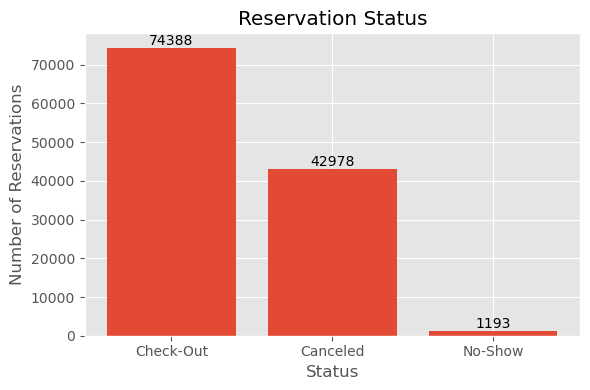

In [41]:
status_counts = df["reservation_status"].value_counts()

plt.figure(figsize=(6,4))

bars = plt.bar(status_counts.index, status_counts.values)

plt.title("Reservation Status")
plt.xlabel("Status")
plt.ylabel("Number of Reservations")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

The majority of reservations (62.74%) ended with a successful **Check-Out**.

At the same time, more than one-third of all bookings (36.25%) were **Canceled**, showing that cancellations are a significant part of the dataset and deserve further analysis.

Only 1.01% of reservations were recorded as **No-Show**, making this the least common booking outcome.

## 💰 Average Daily Rate (ADR)

The Average Daily Rate (ADR) represents the average price paid for a booked room.

In this section, we compare ADR between City Hotels and Resort Hotels to identify possible differences in room pricing.

### 🔍 Key Findings

- City Hotels had a higher average daily rate (€105.79) than Resort Hotels (€95.90).
- On average, bookings at City Hotels were approximately €10 more expensive per night.

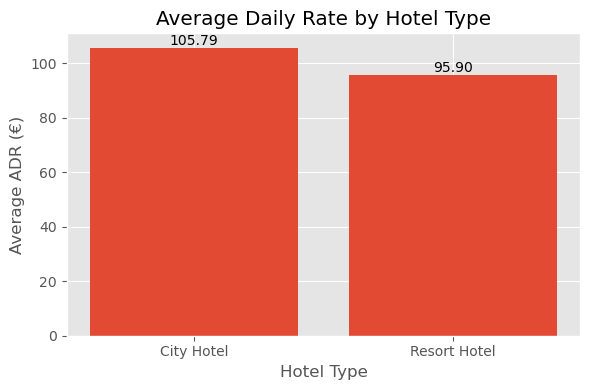

In [59]:
adr_mean = df.groupby("hotel")["adr"].mean().round(2)

plt.figure(figsize=(6,4))

bars = plt.bar(adr_mean.index, adr_mean.values)

plt.title("Average Daily Rate by Hotel Type")
plt.xlabel("Hotel Type")
plt.ylabel("Average ADR (€)")

plt.bar_label(bars, fmt="%.2f")

plt.tight_layout()
plt.show()

## 🌞 Booking Seasonality

Booking demand changes throughout the year, especially between City Hotels and Resort Hotels.

In this section, we compare monthly booking counts to identify seasonal trends for both hotel types.

### 🔍 Key Findings

- City Hotels received more bookings than Resort Hotels in every month.
- Both hotel types reached their highest booking volume during July and August.
- Resort Hotels show a stronger summer peak, suggesting higher seasonal demand.

<Figure size 1000x500 with 0 Axes>

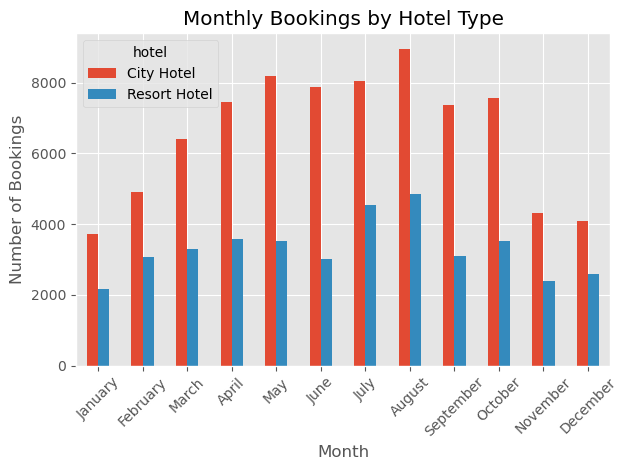

In [68]:
plt.figure(figsize=(10,5))

bookings_month.plot(kind="bar")

plt.title("Monthly Bookings by Hotel Type")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## 🌍 Top Booking Countries

Guests in the dataset come from many different countries.

In this section, we identify the countries with the highest number of hotel bookings.

### 🔍 Key Findings

- Portugal (PRT) accounted for the largest number of bookings, with 47,938 reservations.
- The United Kingdom (GBR) and France (FRA) ranked second and third with 12,094 and 10,389 bookings.
- Most bookings came from European countries, suggesting that the hotels mainly served guests from nearby destinations.

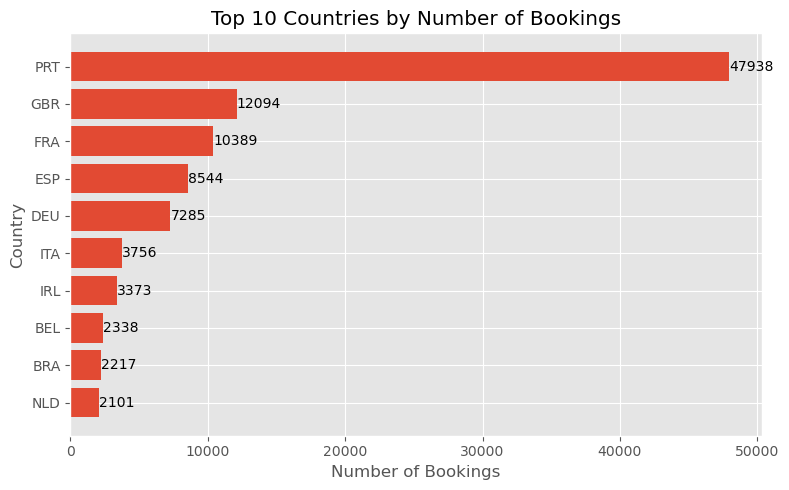

In [75]:
top_countries = df["country"].value_counts().head(10)

plt.figure(figsize=(8,5))

bars = plt.barh(top_countries.index[::-1], top_countries.values[::-1])

plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Number of Bookings")
plt.ylabel("Country")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

## 🍽️ Meal Distribution

Different meal plans were selected when making hotel reservations.

In this section, we examine which meal types were chosen most frequently by guests.

### 🔍 Key Findings

- Bed & Breakfast (BB) was by far the most popular meal option, with 91,715 bookings.
- Half Board (HB) and Self Catering (SC) were selected much less frequently.
- Full Board (FB) and Undefined meal plans represented only a small share of all reservations.

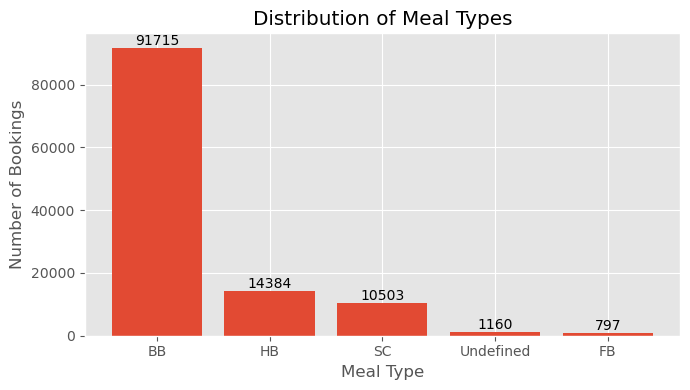

In [80]:
meal_counts = df["meal"].value_counts()

plt.figure(figsize=(7,4))

bars = plt.bar(meal_counts.index, meal_counts.values)

plt.title("Distribution of Meal Types")
plt.xlabel("Meal Type")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

## 💳 Deposit Types

Hotels may require different types of deposits when a reservation is made.

In this section, we examine how bookings are distributed across different deposit types.

### 🔍 Key Findings

- Most bookings (103,811) were made without any deposit.
- Non-refundable deposits were much less common, with 14,586 reservations.
- Refundable deposits were very rare, accounting for only 162 bookings.

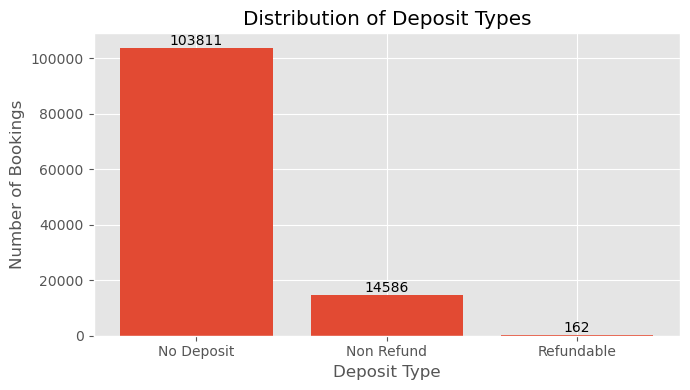

In [85]:
deposit_counts = df["deposit_type"].value_counts()

plt.figure(figsize=(7,4))

bars = plt.bar(deposit_counts.index, deposit_counts.values)

plt.title("Distribution of Deposit Types")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

## 🛏️ Reserved Room Types

Hotels offer several room types, which are represented in the dataset by letter codes.

In this section, we examine how frequently each room type was reserved.

### 🔍 Key Findings

- Room Type A was by far the most frequently reserved room, with 85,396 bookings.
- Room Types D and E were the next most common choices.
- The remaining room types were selected much less frequently, while Room Type L appeared only a few times.

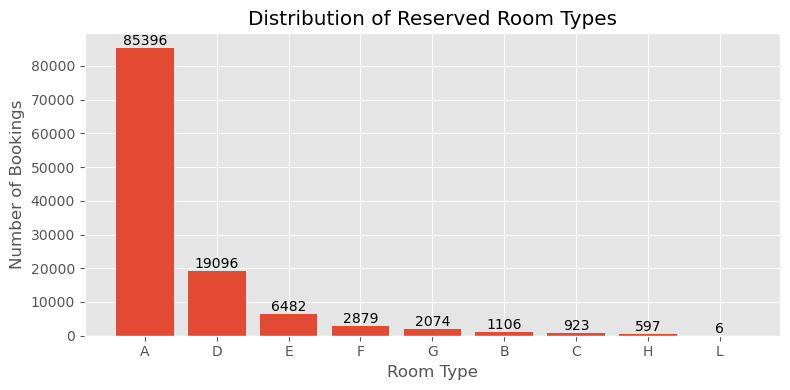

In [92]:
room_counts = df["reserved_room_type"].value_counts()

plt.figure(figsize=(8,4))

bars = plt.bar(room_counts.index, room_counts.values)

plt.title("Distribution of Reserved Room Types")
plt.xlabel("Room Type")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

## 👨‍👩‍👧‍👦 Guest Composition

Reservations may include different numbers of guests, from solo travelers to families and larger groups.

In this section, we examine the total number of guests included in each booking.

### 🔍 Key Findings

- Bookings for two guests were by far the most common, with more than 81,000 reservations.
- Reservations for one and three guests were the next most frequent.
- Bookings with more than five guests were very rare and all of them were cancelled as we know from data cleaning

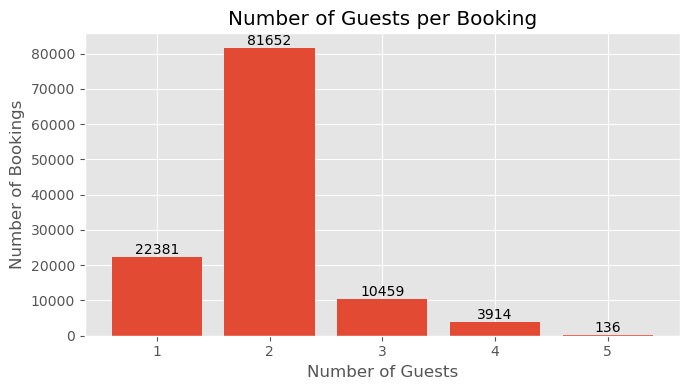

In [100]:
group_size = (
    df["adults"] +
    df["children"] +
    df["babies"]
)

group_counts = (
    group_size[group_size <= 5]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(7,4))

bars = plt.bar(group_counts.index.astype(int).astype(str), group_counts.values)

plt.title("Number of Guests per Booking")
plt.xlabel("Number of Guests")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

## 🔄 Repeated Guests

Some guests have stayed at the hotel before, while others are making their first reservation.

In this section, we examine the proportion of new and returning guests.

### 🔍 Key Findings

- Most reservations were made by new guests.
- Only 3,498 bookings were made by returning guests.
- Repeat guests represent a relatively small share of all hotel reservations.

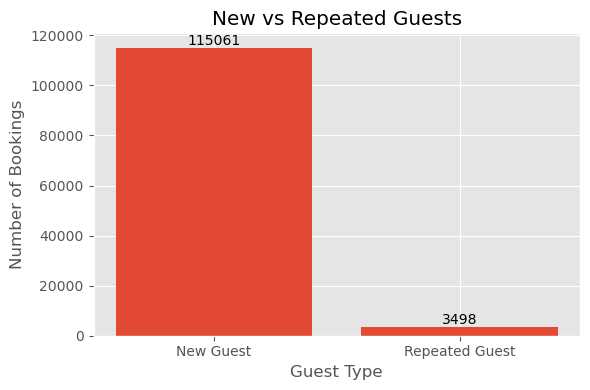

In [105]:
repeat_counts = df["is_repeated_guest"].value_counts()

labels = ["New Guest", "Repeated Guest"]

plt.figure(figsize=(6,4))

bars = plt.bar(labels, repeat_counts.values)

plt.title("New vs Repeated Guests")
plt.xlabel("Guest Type")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

## 📆 Lead Time Distribution

Lead time represents the number of days between making a reservation and the guest's arrival date.

In this section, we examine how far in advance guests typically make their bookings.

### 🔍 Key Findings

- Most reservations were made within the first few months before arrival.
- The distribution is right-skewed, meaning that a small number of guests booked far in advance.
- The average lead time was approximately 105 days.

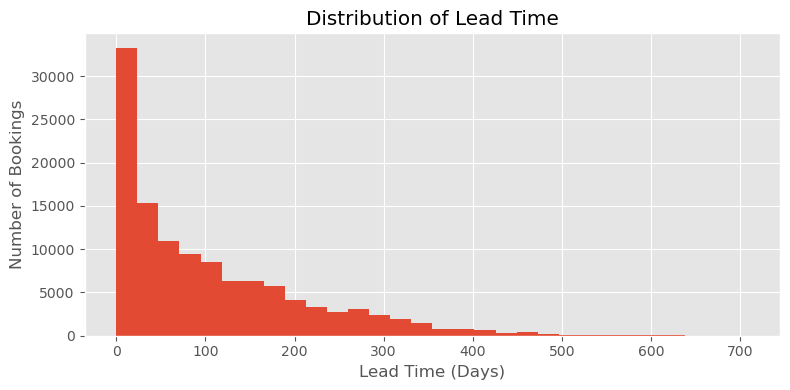

In [111]:
plt.figure(figsize=(8,4))

plt.hist(df["lead_time"], bins=30)

plt.title("Distribution of Lead Time")
plt.xlabel("Lead Time (Days)")
plt.ylabel("Number of Bookings")

plt.tight_layout()
plt.show()

## ⭐ Special Requests

Guests may include special requests when making a reservation, such as requesting a specific room, extra services, or other preferences.

In this section, we examine how many special requests were made per booking.

### 🔍 Key Findings

- Most bookings did not include any special requests.
- One special request was the second most common outcome.
- Reservations with three or more special requests were relatively uncommon.

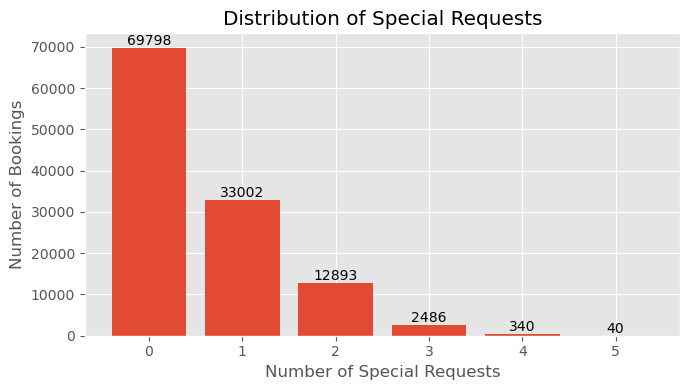

In [117]:
special_requests = df["total_of_special_requests"].value_counts().sort_index()

plt.figure(figsize=(7,4))

bars = plt.bar(special_requests.index.astype(str), special_requests.values)

plt.title("Distribution of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Number of Bookings")

plt.bar_label(bars, fmt="%.0f")

plt.tight_layout()
plt.show()

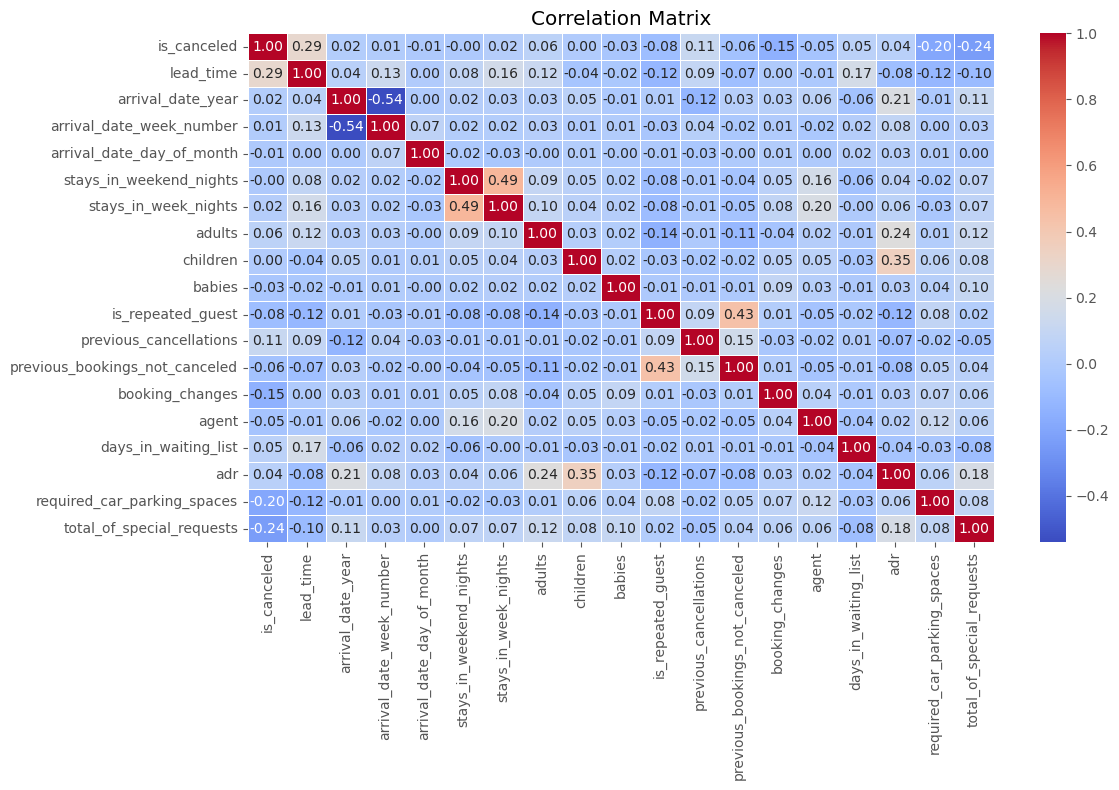

In [119]:
import seaborn as sns

numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## ⭐📉 Special Requests and Cancellation Rate

Guests can include special requests when making a reservation.

In this section, we examine whether the number of special requests is related to reservation cancellations.

### 🔍 Key Findings

- Bookings without any special requests had the highest cancellation rate (48.02%).
- The cancellation rate decreased as the number of special requests increased.
- Guests with five special requests had the lowest cancellation rate (5.00%).
- This suggests that guests who make more special requests are generally more committed to their reservation.

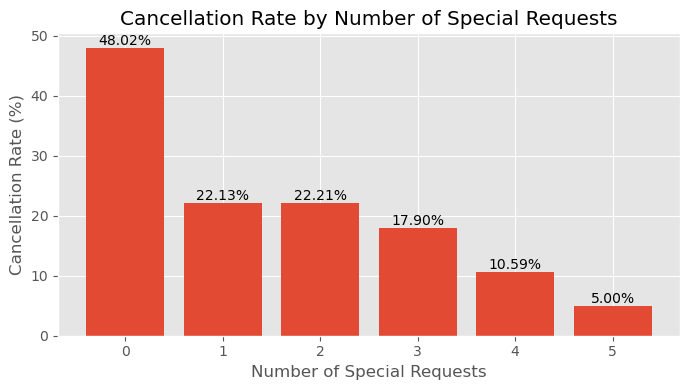

In [127]:
cancel_rate = (
    df.groupby("total_of_special_requests")["is_canceled"]
      .mean()
      .mul(100)
      .round(2)
)

plt.figure(figsize=(7,4))

bars = plt.bar(
    cancel_rate.index.astype(str),
    cancel_rate.values
)

plt.title("Cancellation Rate by Number of Special Requests")
plt.xlabel("Number of Special Requests")
plt.ylabel("Cancellation Rate (%)")

plt.bar_label(bars, fmt="%.2f%%")

plt.tight_layout()
plt.show()

## 👨‍👩‍👧‍👦 Average Daily Rate by Number of Children

The number of children included in a booking may influence the room type and, consequently, the average daily rate.

In this section, we compare the average daily rate for bookings with 0, 1, and 2 children.

### 🔍 Key Findings

- Bookings with children had a higher average daily rate than bookings without children.
- Reservations with two children had the highest average daily rate among the analyzed groups.
- This suggests that families tend to book more expensive rooms than guests traveling without children.

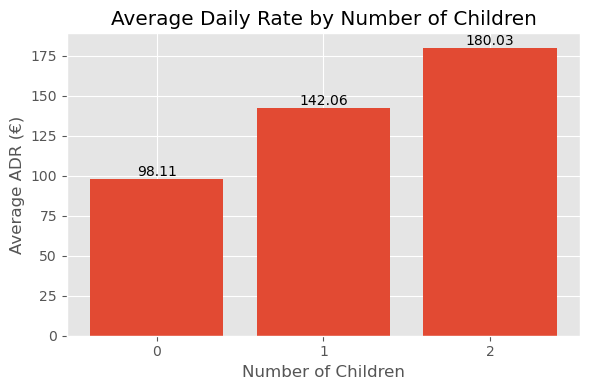

In [132]:
adr_children = (
    df[df["children"] <= 2]
    .groupby("children")["adr"]
    .mean()
    .round(2)
)

plt.figure(figsize=(6,4))

bars = plt.bar(
    adr_children.index.astype(int).astype(str),
    adr_children.values
)

plt.title("Average Daily Rate by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average ADR (€)")

plt.bar_label(bars, fmt="%.2f")

plt.tight_layout()
plt.show()

## ⏳ Lead Time and Reservation Status

Lead time represents the number of days between making a reservation and the guest's arrival.

In this section, we compare the average lead time of completed and canceled reservations.

### 🔍 Key Findings

- Canceled reservations had a much longer average lead time (145 days) than completed reservations (80 days).
- Guests who booked further in advance were more likely to cancel their reservation.

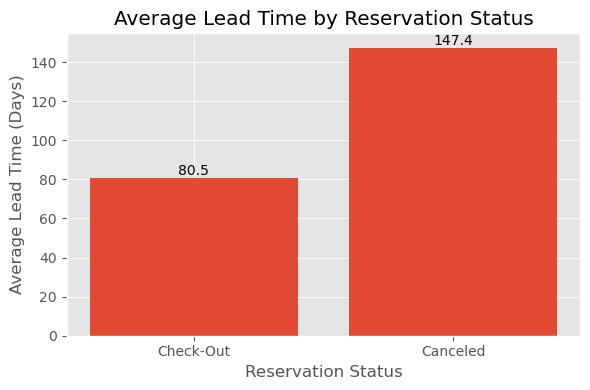

In [135]:
lead_time_mean = (
    df.groupby("reservation_status")["lead_time"]
      .mean()
      .reindex(["Check-Out", "Canceled"])
)

plt.figure(figsize=(6,4))

bars = plt.bar(lead_time_mean.index, lead_time_mean.values)

plt.title("Average Lead Time by Reservation Status")
plt.xlabel("Reservation Status")
plt.ylabel("Average Lead Time (Days)")

plt.bar_label(bars, fmt="%.1f")

plt.tight_layout()
plt.show()

# 📝 EDA Summary

### Main Findings

- City Hotels received more bookings than Resort Hotels.
- Booking demand was highest during summer.
- City Hotels had a higher average daily rate.
- Portugal generated the largest number of bookings.
- Most reservations were made without a deposit.
- Longer lead times were associated with more cancellations.
- Families with children tended to book more expensive rooms.
- Guests with more special requests were less likely to cancel.

In [174]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [176]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118559 entries, 0 to 118558
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           118559 non-null  object 
 1   is_canceled                     118559 non-null  int64  
 2   lead_time                       118559 non-null  int64  
 3   arrival_date_year               118559 non-null  int64  
 4   arrival_date_month              118559 non-null  object 
 5   arrival_date_week_number        118559 non-null  int64  
 6   arrival_date_day_of_month       118559 non-null  int64  
 7   stays_in_weekend_nights         118559 non-null  int64  
 8   stays_in_week_nights            118559 non-null  int64  
 9   adults                          118559 non-null  int64  
 10  children                        118559 non-null  float64
 11  babies                          118559 non-null  int64  
 12  meal            